In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END


In [2]:
class GreetState(BaseModel):
    message : str =""

In [3]:
graph = StateGraph(GreetState)

In [4]:
def Greet(state: GreetState):
    state.message = f"{state.message}!All Good!"
    return state

In [5]:
def smaller(state: GreetState):
    state.message = state.message.lower()
    return state

In [6]:
graph.add_node("greet", Greet)

In [7]:
graph.add_node("lower", smaller)

In [8]:
graph.add_edge(START,"greet")

In [9]:
graph.add_edge("greet","lower")
graph.add_edge("lower",END)

In [10]:
final = graph.compile()

In [11]:
res = final.invoke({"message":"I Love LangGraph!"})
res

{'message': 'i love langgraph!!all good!'}

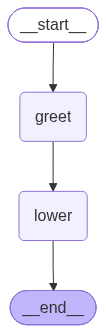

In [13]:
from IPython.display import Image
Image(final.get_graph().draw_mermaid_png())